In [120]:
from ploting_profiles import prepare_box_plot_expression

from shiny import ui, render, App
import pandas as pd
from ploting_profiles import violin_plot_grouped_by_sex_and_age_group, box_plot_expression_by_age_and_sex, prepare_box_plot_expression, prepare_violin_plot_expression
import matplotlib.pyplot as plt

# Load the datasets
expression_data = pd.read_csv("data/RNAseq_z_score_adjustedCombat_symbols.csv")
male_expression = pd.read_csv("data/RNAseq_z_score_adjustedCombat_symbols_male.csv", index_col=0)
female_expression = pd.read_csv("data/RNAseq_z_score_adjustedCombat_symbols_female.csv", index_col=0)
expression_data_mf = pd.concat([male_expression, female_expression], axis=0)

In [116]:
inmmonse_path = '/home/karen/Documents/GitHub/Transcription_factor_analysis/results/RNAseq_abundances_adjusted_combat_inmose_gene_symbol_expression.csv'
inmmonse_data = pd.read_csv(inmmonse_path, header=0)
inmmonse_data

,Sample,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,...,C4orf36.1,TUSC2P1,Unnamed: 34327,OR4M2-OT1,H2BK1,OR1Q1BP,Unnamed: 34331,Unnamed: 34332,TBCEL-TECTA,Age
0,SRR13758984,21281762,0,15759712,0,11295483,0,35294310,0,18333093,...,12741169,0,0,0,0,0,0,2773,0,91.0
1,SRR13758985,8542646,0,15035432,0,0,0,26637602,0,1389125,...,10663212,0,0,0,0,0,0,1328,0,86.0
2,SRR13758986,4079945,0,5410942,0,5658191,0,10946301,4491317,7747412,...,4248288,0,0,0,0,0,0,1,0,69.0
3,SRR13758987,14758557,0,12809471,0,0,0,24093106,0,11562944,...,10497182,0,0,0,0,0,0,1614,0,83.0
4,SRR13758988,3623061,0,15529838,23957067,0,0,25492722,10773730,12889518,...,10506926,0,0,0,0,0,0,795,0,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,SRR1555210,37402439,0,21355420,1,1212397,1,87213838,3370216,5884457,...,23486240,0,0,0,0,0,0,0,5351828,27.5
266,SRR1555211,48027788,0,89024445,1348907,24399,1,148387777,3685378,113719675,...,34582470,0,0,0,1956002,0,0,0,0,27.5
267,SRR1555212,84899250,0,167383416,407713,37284600,1,219777948,58357903,79405469,...,81916604,0,1537700,0,824055,0,1040940,12712840,5952181,27.5
268,SRR1555213,35885217,1428536,44248179,19331,2896856,110080,73026055,17457124,30839652,...,12211531,0,0,0,873096,0,0,0,0,27.5


In [121]:
expression_data[expression_data['Sample']=='SRR13758984']

,Sample,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC007846.2,AC134980.5,AC139491.7,AC021097.2,AC135068.11,AC010616.2,AL034430.1,AP000646.1,Age,Experiment
135,SRR13758984,-0.018401,-0.036692,-0.003063,-0.032864,-0.033612,-0.035171,-0.021175,-0.028672,-0.023496,...,-0.036354,-0.036447,-0.0364,-0.035459,-0.036406,-0.03642,-0.026739,-0.036257,91.0,GSE167186


In [117]:
inmmonse_data.head()

,Sample,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,...,C4orf36.1,TUSC2P1,Unnamed: 34327,OR4M2-OT1,H2BK1,OR1Q1BP,Unnamed: 34331,Unnamed: 34332,TBCEL-TECTA,Age
0,SRR13758984,21281762,0,15759712,0,11295483,0,35294310,0,18333093,...,12741169,0,0,0,0,0,0,2773,0,91.0
1,SRR13758985,8542646,0,15035432,0,0,0,26637602,0,1389125,...,10663212,0,0,0,0,0,0,1328,0,86.0
2,SRR13758986,4079945,0,5410942,0,5658191,0,10946301,4491317,7747412,...,4248288,0,0,0,0,0,0,1,0,69.0
3,SRR13758987,14758557,0,12809471,0,0,0,24093106,0,11562944,...,10497182,0,0,0,0,0,0,1614,0,83.0
4,SRR13758988,3623061,0,15529838,23957067,0,0,25492722,10773730,12889518,...,10506926,0,0,0,0,0,0,795,0,71.0


In [128]:
# expression_data has column Experiment. Map the Sample from inmmonse_data and expression_data and add a new column in inmmonse_data with the corresponding Experiment value.
expression_data_dict = dict(zip(expression_data['Sample'], expression_data['Experiment']))
inmmonse_data['Experiment'] = inmmonse_data['Sample'].map(expression_data_dict)
inmmonse_data.head()

,Sample,TSPAN6,TNMD,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,...,Unnamed: 34327,OR4M2-OT1,H2BK1,OR1Q1BP,Unnamed: 34331,Unnamed: 34332,TBCEL-TECTA,Age,Age Group,Experiment
0,SRR13758984,21281762,0,15759712,0,11295483,0,35294310,0,18333093,...,0,0,0,0,0,2773,0,91.0,"[90.0, 100.0)",GSE167186
1,SRR13758985,8542646,0,15035432,0,0,0,26637602,0,1389125,...,0,0,0,0,0,1328,0,86.0,"[80.0, 90.0)",GSE167186
2,SRR13758986,4079945,0,5410942,0,5658191,0,10946301,4491317,7747412,...,0,0,0,0,0,1,0,69.0,"[60.0, 70.0)",GSE167186
3,SRR13758987,14758557,0,12809471,0,0,0,24093106,0,11562944,...,0,0,0,0,0,1614,0,83.0,"[80.0, 90.0)",GSE167186
4,SRR13758988,3623061,0,15529838,23957067,0,0,25492722,10773730,12889518,...,0,0,0,0,0,795,0,71.0,"[70.0, 80.0)",GSE167186


In [105]:
from ploting_profiles import plot_expression_over_age

In [2]:
selected_genes_file = "data/selected_genes.txt"
with open(selected_genes_file, "r") as file:
    choices = file.read().splitlines()

In [152]:
gene = 'AK1'
plot_type = 'Box Plot'
grouping = False
split_sex = False

gene_data=expression_data
gene= gene
age_group=grouping
sex_div=split_sex
save=None
plot=False
check_significance=True
color='green'
test="t-test_ind"


/tmp/ipykernel_334118/638080151.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Sex", fontsize=12, title_fontsize=14)


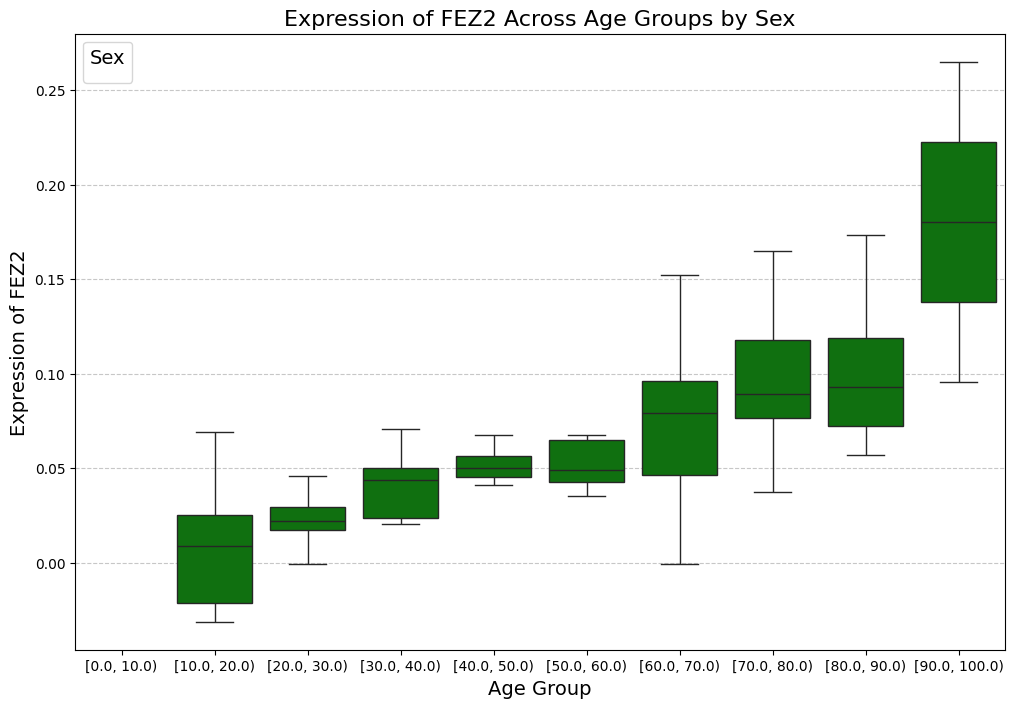

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import seaborn as sns
from scipy.stats import ttest_ind
import plotly.express as px
import plotly.graph_objects as go

from statannotations.Annotator import Annotator
import itertools

    # Define age groups
bins = [18, 35, 65, 100]
labels = ['Young', 'Middle Age', 'Old']
palette = {'Male': 'blue', 'Female': 'pink'}
sig_p_value = 0.05
default_color = 'green'


if age_group:
    age_grouping = pd.cut(gene_data['Age'], bins=bins, labels=labels, right=False)
else:
    age_grouping = pd.cut(
    gene_data['Age'], 
    bins=np.arange(0, gene_data['Age'].max() + 10, 10), 
    right=False
    )

gene_data['Age Group'] = age_grouping
    


# Initialize the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Create the box plots, ignore outliers
sns.boxplot(
    x='Age Group',
    y=gene,
    data=gene_data,
    color=color,
    showfliers=False
)


# Customize the plot
plt.title(f"Expression of {gene} Across Age Groups by Sex", fontsize=16)
plt.xlabel("Age Group", fontsize=14)
plt.ylabel(f"Expression of {gene}", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Sex", fontsize=12, title_fontsize=14)

# Save the plot if a file path is provided
if save:
    plt.savefig(save, bbox_inches='tight')

# Show the plot
if plot:
    plt.show()


In [102]:
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

def significance_heatmap(gene_data, gene, alpha=0.05, test="t-test_ind", cmap=sns.cubehelix_palette(as_cmap=True), save=None, plot=True):
    """
    Create a heatmap of significant pairwise differences between age groups.
    
    Parameters:
        gene_data (pd.DataFrame): Data with 'Age Group' column and expression values.
        gene (str): Column name for gene expression values.
        alpha (float): Significance threshold.
        test (str): Currently supports "t-test_ind".
        cmap (str): Colormap for the heatmap.
    """
    groups = gene_data['Age Group'].unique()
    comparisons = list(itertools.combinations(groups, 2))

    # Initialize result matrix
    result_matrix = pd.DataFrame(0.0, index=groups, columns=groups)
    
    for g1, g2 in comparisons:
        data1 = gene_data.loc[gene_data['Age Group'] == g1, gene]
        data2 = gene_data.loc[gene_data['Age Group'] == g2, gene]
        
        if test == "t-test_ind":
            stat, pval = ttest_ind(data1, data2, nan_policy="omit")
        else:
            raise ValueError(f"Test {test} not implemented yet.")
        
        # Only keep significant results
        if pval < alpha:
            result_matrix.loc[g1, g2] = stat
            result_matrix.loc[g2, g1] = -stat  # symmetric
    
    # Replace 0 with NaN for cleaner heatmap
    result_matrix = result_matrix.replace(0, np.nan)
    # move only the last result_matrix row and column to the first
    result_matrix = result_matrix.reindex(index=[result_matrix.index[-1]] + list(result_matrix.index[:-1]))
    result_matrix = result_matrix.reindex(columns=[result_matrix.columns[-1]] + list(result_matrix.columns[:-1]))
    # Plot heatmap
    plt.figure(figsize=(10, 8))
    max_abs = np.nanmax(np.abs(result_matrix.values))
    #sns.heatmap(result_matrix, annot=True, fmt=".2f", cmap=cmap, cbar_kws={'label': 't-statistic'})
    sns.heatmap(
        result_matrix,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        center=0,                 # Important: sets 0 as center
        vmin=-max_abs,             # Symmetric limits
        vmax=max_abs,
        cbar_kws={'label': 't-statistic'}
    )
    plt.title(f"Significant Pairwise Differences in {gene}", fontsize=16)
    if save:
        plt.savefig(save, bbox_inches='tight')
    if plot:
        plt.show()

    return result_matrix

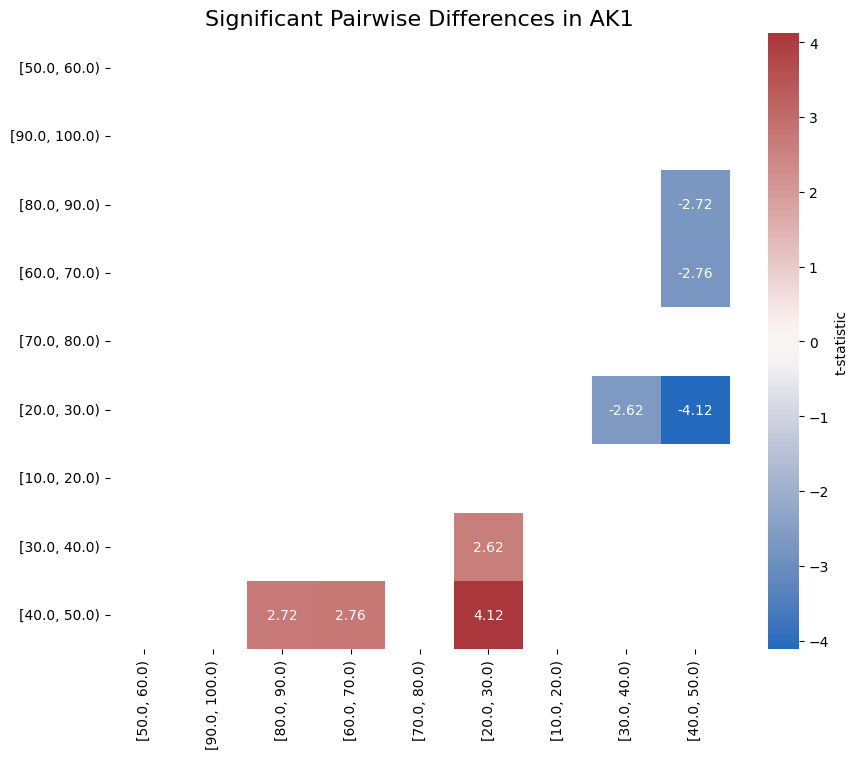

/tmp/ipykernel_334118/1108869285.py:46: RuntimeWarning: All-NaN slice encountered
  max_abs = np.nanmax(np.abs(result_matrix.values))


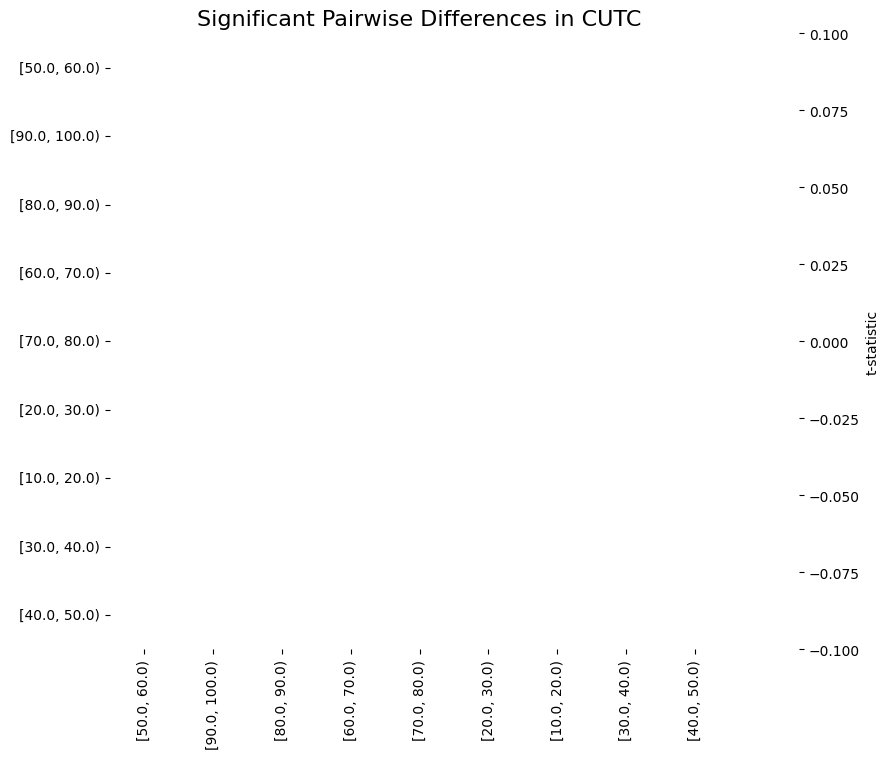

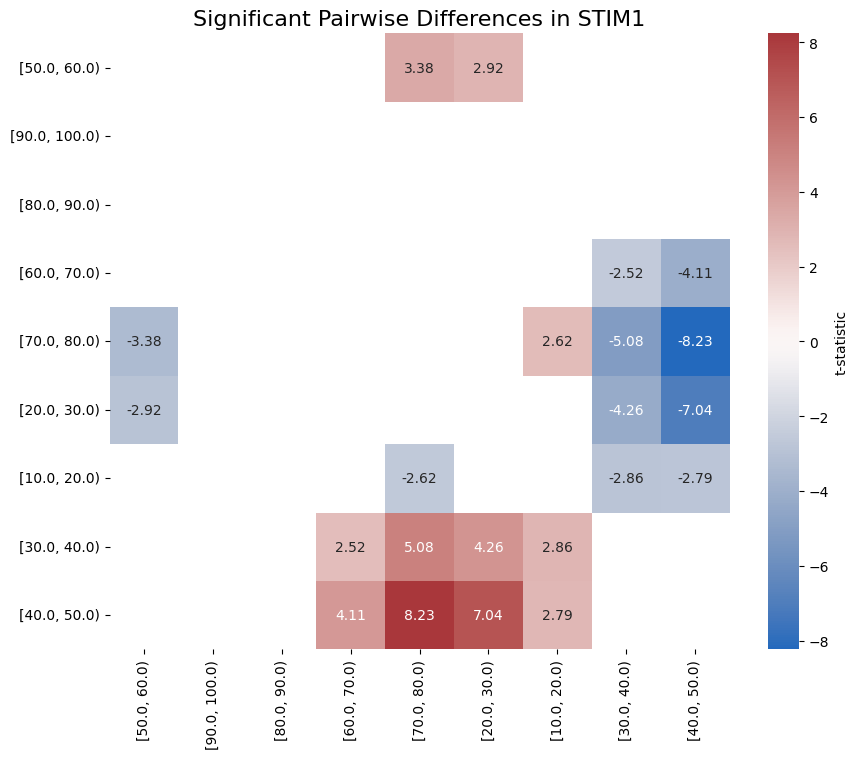

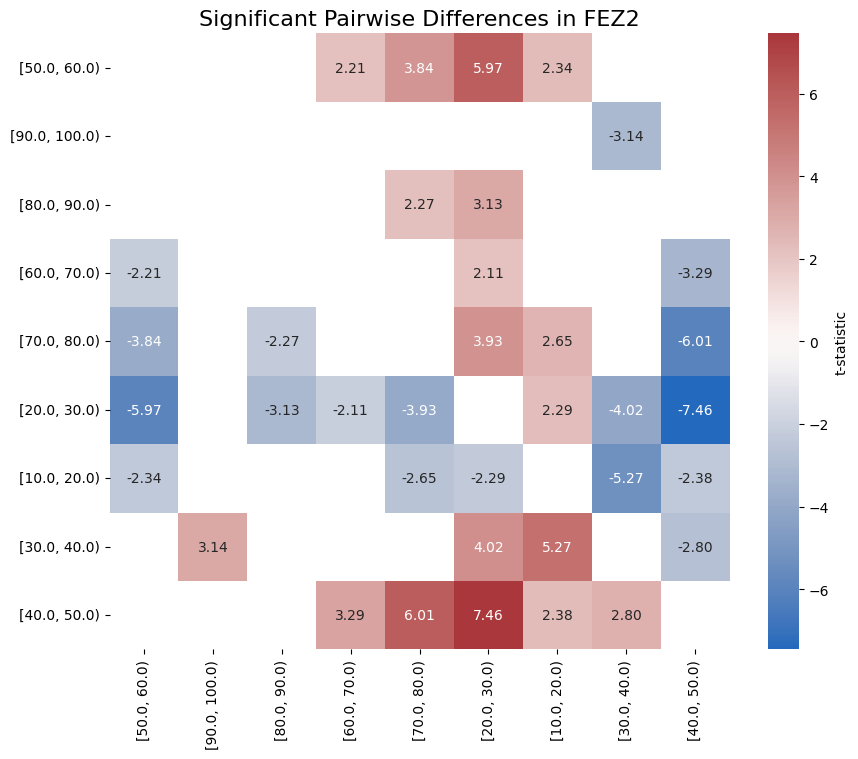

In [124]:
result_matrixes = {}
for gene in ['AK1', 'CUTC', 'STIM1', 'FEZ2']:
    result_matrixes[gene] = significance_heatmap(gene_data, gene, alpha=0.05, 
                                                 test="t-test_ind", 
                                                 cmap = sns.color_palette("vlag", as_cmap=True),
                                                 save=None, plot=True)

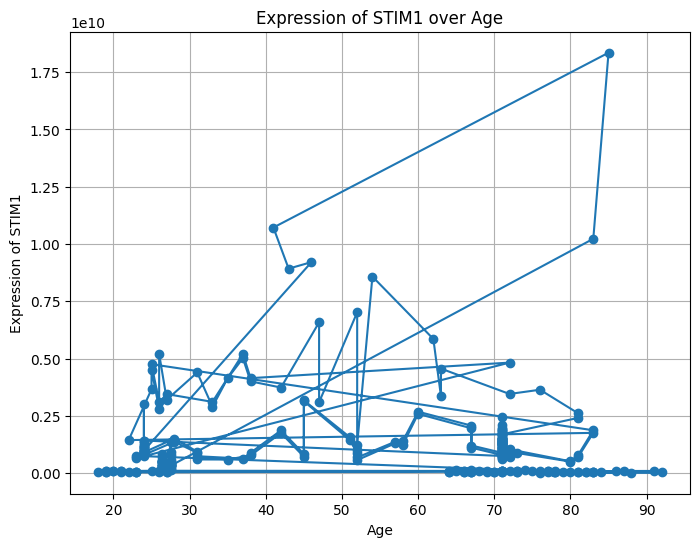

In [125]:
plot_expression_over_age(gene_data, gene='STIM1',save=None, plot=True)

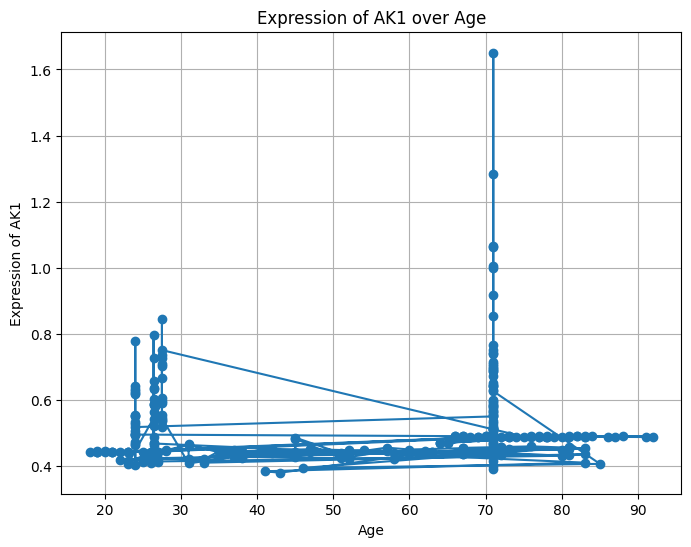

In [109]:
plot_expression_over_age(gene_data, gene='AK1',save=None, plot=True)

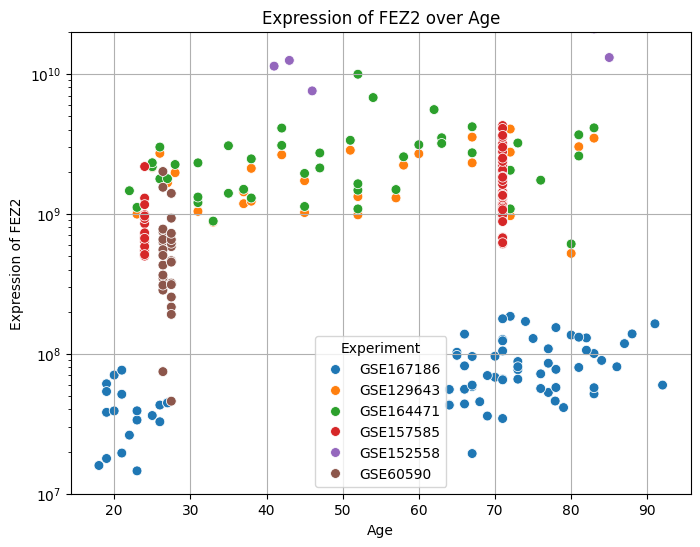

In [143]:
gene = 'FEZ2'
# I will plot from 0 to 1x10^9  
plt.figure(figsize=(8, 6))

# Scatter plot colored by 'experiment'
sns.scatterplot(
    data=gene_data,
    x='Age',
    y=gene,
    hue='Experiment',
    palette='tab10',  # You can choose any palette
    s=50  # marker size
)
plt.yscale('log')
plt.ylim(1e7, 2e10)
# Customize the plot
plt.title(f"Expression of {gene} over Age")
plt.xlabel("Age")
plt.ylabel(f"Expression of {gene}")
plt.grid(True)
plt.legend(title='Experiment')

if save:
    plt.savefig(save, bbox_inches='tight')
if plot:
    plt.show()

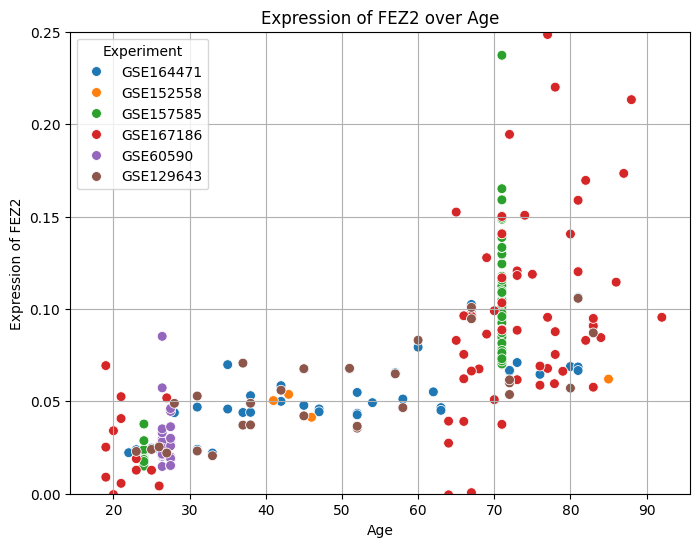

In [179]:
gene = 'FEZ2'
# I will plot from 0 to 1x10^9  
plt.figure(figsize=(8, 6))

# Scatter plot colored by 'experiment'
sns.scatterplot(
    data=gene_data,
    x='Age',
    y=gene,
    hue='Experiment',
    palette='tab10',  # You can choose any palette
    s=50  # marker size
)
#plt.yscale('log')
plt.ylim(0.0, 0.25)
# Customize the plot
plt.title(f"Expression of {gene} over Age")
plt.xlabel("Age")
plt.ylabel(f"Expression of {gene}")
plt.grid(True)
plt.legend(title='Experiment')

if save:
    plt.savefig(save, bbox_inches='tight')
if plot:
    plt.show()

In [108]:
gene_data

,Sample,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,...,AC139491.7,AC021097.2,AC135068.11,AC010616.2,AL034430.1,AP000646.1,Age,Experiment,Sex,Age Group
0,SRR13388732,-0.024640,-0.027469,-0.007903,-0.026124,-0.026015,-0.026864,-0.021406,-0.022678,-0.022670,...,-0.027267,-0.026753,-0.027502,-0.027457,-0.024058,-0.027476,23.0,GSE164471,Male,"[20.0, 30.0)"
1,SRR13388733,-0.025765,-0.032593,-0.006575,-0.027678,-0.031369,-0.031862,-0.016857,-0.026578,-0.023808,...,-0.032619,-0.031722,-0.032605,-0.032541,-0.020310,-0.031807,28.0,GSE164471,Male,"[20.0, 30.0)"
2,SRR13388734,-0.030008,-0.036930,-0.005061,-0.034131,-0.029369,-0.037718,-0.015247,-0.030479,-0.027006,...,-0.038491,-0.037602,-0.038201,-0.038558,-0.036063,-0.037850,31.0,GSE164471,Male,"[30.0, 40.0)"
3,SRR13388735,-0.021340,-0.023615,-0.006280,-0.022375,-0.023463,-0.023325,-0.020330,-0.021371,-0.022376,...,-0.023678,-0.023091,-0.023741,-0.023709,-0.020413,-0.023409,31.0,GSE164471,Male,"[30.0, 40.0)"
6,SRR13388738,-0.025443,-0.030270,-0.001806,-0.026169,-0.027979,-0.029679,-0.021693,-0.026117,-0.022741,...,-0.030203,-0.027980,-0.030294,-0.030219,-0.029668,-0.029403,42.0,GSE164471,Male,"[40.0, 50.0)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,SRR8882188,-0.022294,-0.025986,-0.004224,-0.024760,-0.024410,-0.025135,-0.019103,-0.021640,-0.022767,...,-0.025965,-0.025408,-0.026020,-0.025998,-0.025492,-0.025635,72.0,GSE129643,Female,"[70.0, 80.0)"
260,SRR8882190,-0.018996,-0.029198,-0.007899,-0.025857,-0.013814,-0.027548,-0.023447,-0.013117,-0.020596,...,-0.028548,-0.028935,-0.028896,-0.029621,-0.028055,-0.029281,80.0,GSE129643,Female,"[80.0, 90.0)"
263,SRR8882195,-0.017648,-0.019100,-0.005363,-0.017630,-0.019334,-0.018820,-0.015041,-0.018023,-0.016714,...,-0.019182,-0.018724,-0.019168,-0.019150,-0.017906,-0.019068,25.0,GSE129643,Female,"[20.0, 30.0)"
264,SRR8882196,-0.017762,-0.019471,-0.005234,-0.018451,-0.019700,-0.019186,-0.015858,-0.018344,-0.016909,...,-0.019595,-0.019165,-0.019623,-0.019604,-0.018781,-0.019576,26.0,GSE129643,Female,"[20.0, 30.0)"


In [104]:
import numpy as np
from scipy.stats import kstest, norm
from scipy.stats import shapiro


In [101]:
data = gene_data.loc[gene_data['Age Group'] == "20-29", gene].values


{'AK1':                [10.0, 20.0)  [20.0, 30.0)  [30.0, 40.0)  [40.0, 50.0)  \
 [10.0, 20.0)            NaN           NaN           NaN           NaN   
 [20.0, 30.0)            NaN           NaN      3.646510      3.091031   
 [30.0, 40.0)            NaN     -3.646510           NaN           NaN   
 [40.0, 50.0)            NaN     -3.091031           NaN           NaN   
 [50.0, 60.0)            NaN     -3.187275           NaN           NaN   
 [60.0, 70.0)       2.746788     -2.918246      5.687869      3.728192   
 [70.0, 80.0)            NaN      2.058518      3.076736      2.631944   
 [80.0, 90.0)            NaN     -2.863573      4.012520      2.782664   
 [90.0, 100.0)     73.126873           NaN      4.394846           NaN   
 
                [50.0, 60.0)  [60.0, 70.0)  [70.0, 80.0)  [80.0, 90.0)  \
 [10.0, 20.0)            NaN     -2.746788           NaN           NaN   
 [20.0, 30.0)       3.187275      2.918246     -2.058518      2.863573   
 [30.0, 40.0)            NaN 